In [1]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 3.5 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO

from pathlib import Path
import pandas as pd
import time
import glob

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [3]:
DATA_ROOT = Path(
    "/kaggle/input/datasets/khmtbku2407/traffic-train-ver1/dataset/bdd100k-yolo"
)


print("Dataset:", DATA_ROOT)

print(
    "Train images:",
    (DATA_ROOT / "train/images").exists()
)

print(
    "Val images:",
    (DATA_ROOT / "val/images").exists()
)

print(
    "Test images:",
    (DATA_ROOT / "test/images").exists()
)

Dataset: /kaggle/input/datasets/khmtbku2407/traffic-train-ver1/dataset/bdd100k-yolo
Train images: True
Val images: True
Test images: True


In [4]:
models = {

    "best_final":
    "/kaggle/input/datasets/khmtbku2407/best-traffic/best final.pt",

    "best_2":
    "/kaggle/input/datasets/khmtbku2407/best-traffic/best_2.pt",

    "best_3":
    "/kaggle/input/datasets/khmtbku2407/best-traffic/best_3.pt",

    "best_4":
    "/kaggle/input/datasets/khmtbku2407/best-traffic/best_4.pt"

}


for k,v in models.items():
    print(k,v)

best_final /kaggle/input/datasets/khmtbku2407/best-traffic/best final.pt
best_2 /kaggle/input/datasets/khmtbku2407/best-traffic/best_2.pt
best_3 /kaggle/input/datasets/khmtbku2407/best-traffic/best_3.pt
best_4 /kaggle/input/datasets/khmtbku2407/best-traffic/best_4.pt


In [5]:
yaml_path = "/kaggle/working/bdd100k_val.yaml"

yaml_content = """
path: /kaggle/input/datasets/khmtbku2407/traffic-train-ver1/dataset/bdd100k-yolo

train: train/images
val: val/images
test: test/images

nc: 10

names:
  0: pedestrian
  1: rider
  2: car
  3: bus
  4: truck
  5: bicycle
  6: motor
  7: traffic light
  8: traffic sign
  9: train
"""

with open(yaml_path, "w") as f:
    f.write(yaml_content)

print(yaml_path)

/kaggle/working/bdd100k_val.yaml


In [6]:
print(open("/kaggle/working/bdd100k_val.yaml").read())


path: /kaggle/input/datasets/khmtbku2407/traffic-train-ver1/dataset/bdd100k-yolo

train: train/images
val: val/images
test: test/images

nc: 10

names:
  0: pedestrian
  1: rider
  2: car
  3: bus
  4: truck
  5: bicycle
  6: motor
  7: traffic light
  8: traffic sign
  9: train



In [7]:
from pathlib import Path

root = Path(
"/kaggle/input/datasets/khmtbku2407/traffic-train-ver1/dataset/bdd100k-yolo"
)

print((root/"val/images").exists())
print((root/"val/labels").exists())

True
True


In [8]:
results = {}


for name, path in models.items():

    print("==============================")
    print("Testing:", name)


    model = YOLO(path)


    result = model.val(
        data=yaml_path,
        imgsz=640,
        batch=16,
        device=0,
        verbose=False
    )


    precision = result.box.mp
    recall = result.box.mr


    f1 = (
        2 * precision * recall /
        (precision + recall + 1e-9)
    )


    results[name] = {


        "Precision":
        precision,


        "Recall":
        recall,


        "F1":
        f1,


        "mAP50":
        result.box.map50,


        "mAP50-95":
        result.box.map

    }


    print(results[name])

Testing: best_final
Ultralytics 8.4.171 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11m summary (fused): 126 layers, 20,037,742 parameters, 0 gradients, 67.8 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.9±0.1 ms, read: 12.0±1.1 MB/s, size: 69.1 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /kaggle/input/datasets/khmtbku2407/traffic-train-ver1/dataset/bdd100k-yolo/val/labels... 10000 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10000/10000 221.2it/s 45.2s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/khmtbku2407/traffic-train-ver1/dataset/bdd100k-yolo/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 625/625 3.3it/s 3:12
                   all      10000     185526      0.738       0.53      0.576       0.33
Speed: 0.5ms preprocess,

In [9]:
df = pd.DataFrame(results).T


df = df.sort_values(
    by="mAP50-95",
    ascending=False
)


df

,Precision,Recall,F1,mAP50,mAP50-95
best_final,0.737671,0.529882,0.616745,0.575747,0.329762
best_4,0.740494,0.515692,0.607978,0.563665,0.321853
best_2,0.741212,0.514338,0.607277,0.562243,0.320984
best_3,0.737500,0.509104,0.602379,0.559591,0.318842


In [10]:
df.to_csv(
    "/kaggle/working/model_validation_results.csv"
)


print(
    "Saved!"
)

Saved!


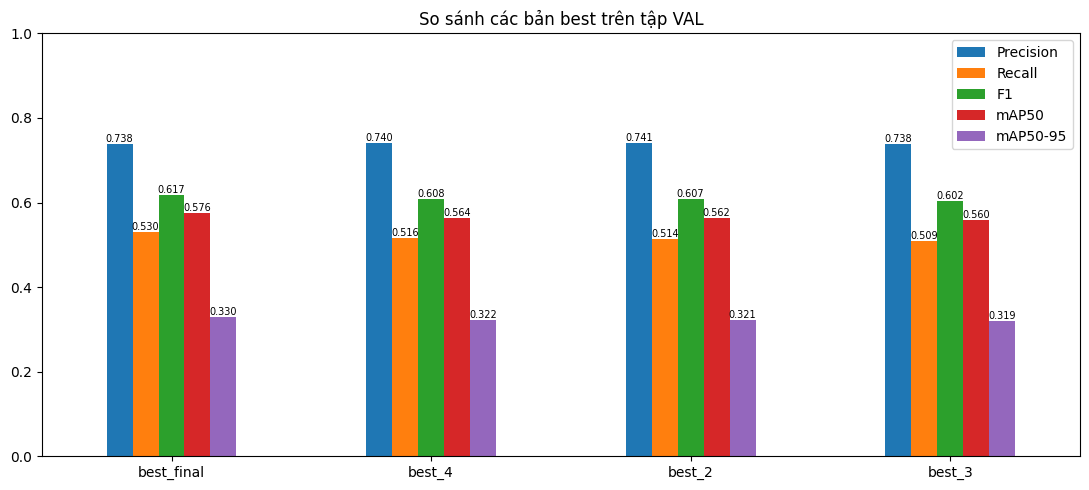

In [11]:
import matplotlib.pyplot as plt
import yaml

metrics = ["Precision", "Recall", "F1", "mAP50", "mAP50-95"]
ax = df[metrics].plot(kind="bar", figsize=(11, 5), rot=0)
ax.set_title("So sánh các bản best trên tập VAL")
ax.set_ylim(0, 1)
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", fontsize=7)
plt.tight_layout()
plt.savefig("/kaggle/working/val_comparison.png", dpi=150)
plt.show()

Bản được chọn: best_final
Ultralytics 8.4.171 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11m summary (fused): 126 layers, 20,037,742 parameters, 0 gradients, 67.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 72.3±35.0 MB/s, size: 62.4 KB)
val: Scanning /kaggle/input/datasets/khmtbku2407/traffic-train-ver1/dataset/bdd100k-yolo/val/labels... 10000 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10000/10000 758.8it/s 13.2s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/khmtbku2407/traffic-train-ver1/dataset/bdd100k-yolo/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 625/625 3.2it/s 3:15
                   all      10000     185526      0.738       0.53      0.576       0.33
Speed: 0.5ms preprocess, 15.0ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /kaggle/working/runs/final_val


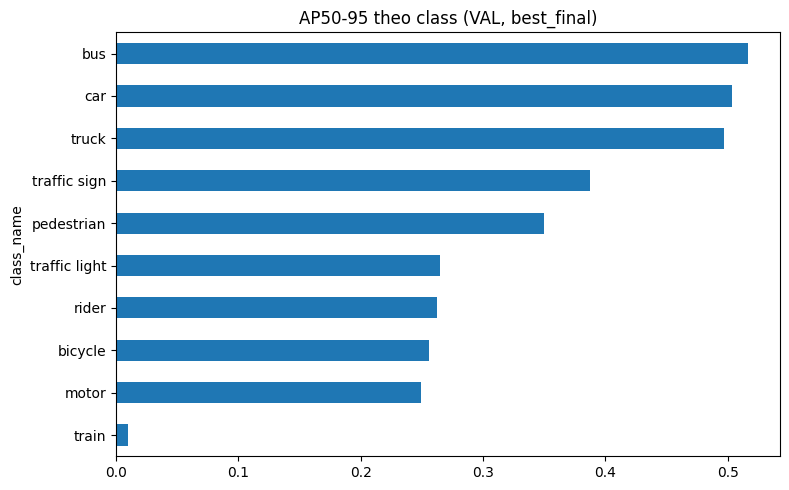

,class_name,AP50-95
0,pedestrian,0.349556
1,rider,0.262671
2,car,0.503636
3,bus,0.516931
4,truck,0.497284
5,bicycle,0.256187
6,motor,0.249111
7,traffic light,0.264933
8,traffic sign,0.387344
9,train,0.009962


In [12]:
names = yaml.safe_load(open(yaml_path))["names"]   # lấy tên từ yaml, không dùng result.names

best_name = df.index[0]
best_model_path = models[best_name]
print("Bản được chọn:", best_name)

model = YOLO(best_model_path)
result = model.val(
    data=yaml_path, split="val", imgsz=640, batch=16, device=0,
    plots=True, project="/kaggle/working/runs", name="final_val",
    exist_ok=True, verbose=False
)

class_df = pd.DataFrame({
    "class_name": [names[i] for i in range(len(result.box.maps))],
    "AP50-95": result.box.maps,
})
class_df.to_csv("/kaggle/working/val_per_class.csv", index=False)

class_df.set_index("class_name")["AP50-95"].sort_values().plot(
    kind="barh", figsize=(8, 5), title=f"AP50-95 theo class (VAL, {best_name})")
plt.tight_layout()
plt.savefig("/kaggle/working/val_per_class.png", dpi=150)
plt.show()
class_df

Ultralytics 8.4.171 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11m summary (fused): 126 layers, 20,037,742 parameters, 0 gradients, 67.8 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.7±0.0 ms, read: 11.3±3.9 MB/s, size: 61.3 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /kaggle/input/datasets/khmtbku2407/traffic-train-ver1/dataset/bdd100k-yolo/test/labels... 20000 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 20000/20000 228.1it/s 1:28
val: /kaggle/input/datasets/khmtbku2407/traffic-train-ver1/dataset/bdd100k-yolo/test/images/e6f10c58-c46de527.jpg: 1 duplicate labels removed
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/khmtbku2407/traffic-train-ver1/dataset/bdd100k-yolo/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1250/1250 3

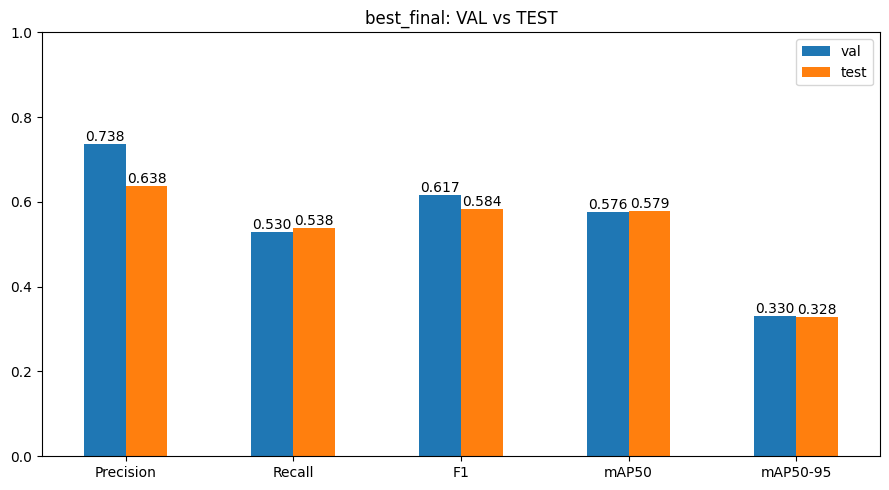

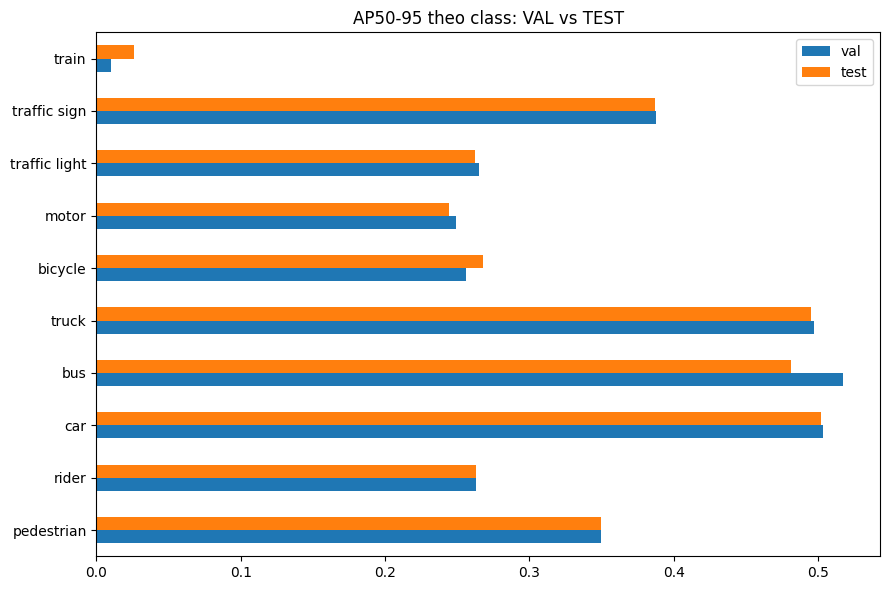

In [13]:
test_result = YOLO(best_model_path).val(
    data=yaml_path, split="test", imgsz=640, batch=16, device=0,
    plots=True, project="/kaggle/working/runs", name="final_test",
    exist_ok=True, verbose=False
)

p, r = test_result.box.mp, test_result.box.mr
test_row = {
    "Precision": p, "Recall": r, "F1": 2*p*r/(p+r+1e-9),
    "mAP50": test_result.box.map50, "mAP50-95": test_result.box.map,
}
val_row = df.iloc[0][metrics].to_dict()

cmp = pd.DataFrame({"val": val_row, "test": test_row})
cmp.to_csv("/kaggle/working/val_vs_test.csv")
print(cmp.round(4))

ax = cmp.plot(kind="bar", figsize=(9, 5), rot=0)
ax.set_title(f"{best_name}: VAL vs TEST")
ax.set_ylim(0, 1)
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f")
plt.tight_layout()
plt.savefig("/kaggle/working/val_vs_test.png", dpi=150)
plt.show()

# AP theo class: val vs test
test_cls = pd.Series(test_result.box.maps, index=[names[i] for i in range(len(names))])
pc = pd.DataFrame({"val": class_df.set_index("class_name")["AP50-95"], "test": test_cls})
pc.to_csv("/kaggle/working/per_class_val_vs_test.csv")
pc.plot(kind="barh", figsize=(9, 6), title="AP50-95 theo class: VAL vs TEST")
plt.tight_layout()
plt.savefig("/kaggle/working/per_class_val_vs_test.png", dpi=150)
plt.show()

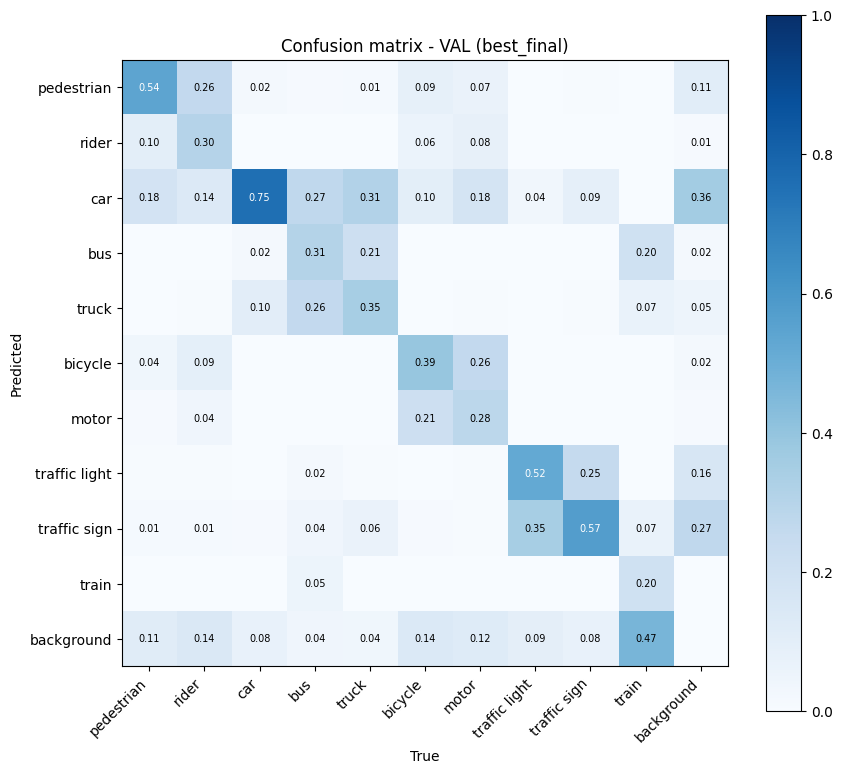

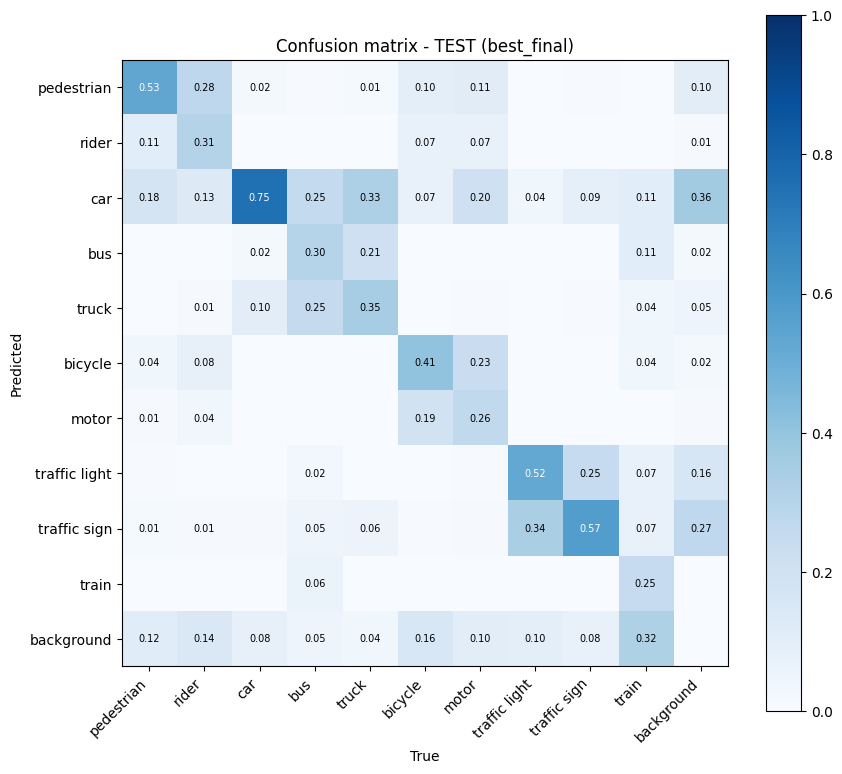

In [14]:
import numpy as np

def plot_cm(res, title, save_path):
    cm = res.confusion_matrix.matrix.astype(float)      # hàng = dự đoán, cột = thật
    cm = cm / (cm.sum(axis=0, keepdims=True) + 1e-9)    # chuẩn hóa theo class thật
    labels = [names[i] for i in range(len(names))] + ["background"]
    fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    ax.set_xlabel("True"); ax.set_ylabel("Predicted"); ax.set_title(title)
    for i in range(len(labels)):
        for j in range(len(labels)):
            if cm[i, j] >= 0.01:
                ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center",
                        fontsize=7, color="white" if cm[i, j] > 0.5 else "black")
    fig.colorbar(im)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

plot_cm(result, f"Confusion matrix - VAL ({best_name})", "/kaggle/working/cm_val.png")
plot_cm(test_result, f"Confusion matrix - TEST ({best_name})", "/kaggle/working/cm_test.png")

In [15]:
def measure_fps(
    model_path,
    num_images=500
):


    model = YOLO(model_path)


    images = glob.glob(
        str(
            DATA_ROOT /
            "val/images/*.jpg"
        )
    )


    images = images[:num_images]


    start = time.time()


    for img in images:


        model.predict(
            img,
            imgsz=640,
            device=0,
            verbose=False
        )


    end=time.time()


    total=end-start


    fps=len(images)/total


    latency=(
        total/len(images)
    )*1000


    return fps, latency

In [16]:
fps_results={}


for name,path in models.items():


    fps,latency = measure_fps(path)


    fps_results[name]={

        "FPS":
        fps,


        "Latency_ms":
        latency

    }


fps_df=pd.DataFrame(fps_results).T


fps_df

,FPS,Latency_ms
best_final,43.670267,22.898875
best_2,48.108526,20.786336
best_3,48.384973,20.667574
best_4,48.444999,20.641965


In [17]:
final_table = df.join(
    fps_df
)


final_table

,Precision,Recall,F1,mAP50,mAP50-95,FPS,Latency_ms
best_final,0.737671,0.529882,0.616745,0.575747,0.329762,43.670267,22.898875
best_4,0.740494,0.515692,0.607978,0.563665,0.321853,48.444999,20.641965
best_2,0.741212,0.514338,0.607277,0.562243,0.320984,48.108526,20.786336
best_3,0.737500,0.509104,0.602379,0.559591,0.318842,48.384973,20.667574


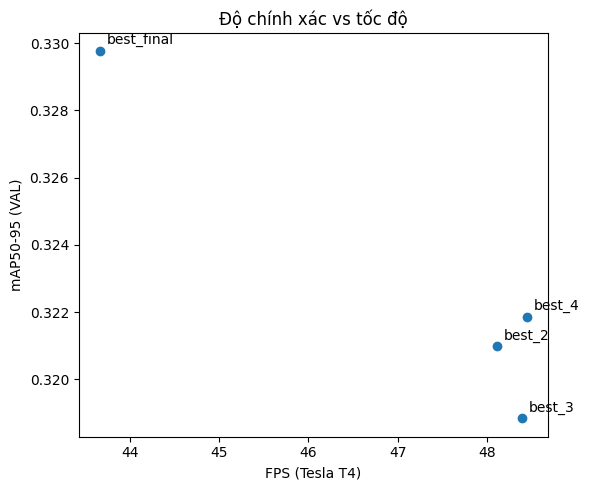

In [18]:
final_table.to_csv("/kaggle/working/final_table.csv")

plt.figure(figsize=(6, 5))
plt.scatter(final_table["FPS"], final_table["mAP50-95"])
for n, row in final_table.iterrows():
    plt.annotate(n, (row["FPS"], row["mAP50-95"]),
                 textcoords="offset points", xytext=(5, 5))
plt.xlabel("FPS (Tesla T4)")
plt.ylabel("mAP50-95 (VAL)")
plt.title("Độ chính xác vs tốc độ")
plt.tight_layout()
plt.savefig("/kaggle/working/acc_vs_fps.png", dpi=150)
plt.show()